### Perceptron
Another linear discriminant function is perceptron. It corresponds to a two-class model in which the input vector $\mathbf{x}$ is first transformed using a non-linear transformation to give a feature vector $\boldsymbol{\phi}(\mathbf{x})$, and then use it to construct a generalized linear model of the form
$$ y=f(\mathbf{w}^T \boldsymbol{\phi}(\mathbf{x})) $$
We assume that the vector $\boldsymbol{\phi}(\mathbf{x})$ typically includes the bias component $\phi_0$. The nonlinear activation function $\mathbf{f}(.)$ is given by a step function of the form
$$
f(\alpha)=
\begin{cases}
+1, & \quad \alpha \geq 0 \\
-1, & \quad \alpha < 0
\end{cases}
$$
That is because for the perception it is more convenient to use target values $t=+1$ for class $C_1$ and $t=-1$ for class $C_2$, instead of $t \in \{ 0,1 \}$. We consider an error function called the *perception criterion*. Note that we are seeking a weight vector $\mathbf{w}$, such that the input $\mathbf{x}_n$, belonging in class $C_1$, have $\mathbf{w}^T \boldsymbol{\phi} (\mathbf{x}_n)>0$, where as the ones belonging in class $C_2$, have $\mathbf{w}^T \boldsymbol{\phi} (\mathbf{x}_n)<0$. Given the coding scheme $t\in \{ -1, +1 \}$, it follows that all inputs must satisfy $\mathbf{w}^T \boldsymbol{\phi} (\mathbf{x}_n)t_n>0$. Thus, the perceptron criterion tries to minimize the quantity $\mathbf{w}^T \boldsymbol{\phi} (\mathbf{x}_n)t_n<0$, for all misclassified inputs. More formally, 
$$ E_P(\mathbf{w}) = \sum_{n=1}^N -\min(0,\mathbf{w}^T \boldsymbol{\phi} (\mathbf{x}_n)t_n) $$
We apply the stochastic gradient descent algorithm to the loss function. Thus, the change in the weight vector, according to gradient descent, is given by
$$ \mathbf{w}^{r+1} = \mathbf{w}^r-\eta \nabla E_p(\mathbf{w})$$

In [2]:
import math
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification

# Set random seed to make deterministic
np.random.seed(0)

In [5]:
# Types
from typing import Union
from typing import Optional

# Standard Library
import functools
import itertools
import abc

class BasisFunction(metaclass=abc.ABCMeta):
    """
    Basis function abstract class.
    """

    @staticmethod
    def _make_array(x: Union[int, float, np.ndarray]) -> np.ndarray:
        """
        Checks if the input is an array. The array should be at most
        2-dimensional, representing one data point per row. If not, an
        exception is raised. In case a single number is given, it creates
        an array containing a single number.

        :param x: (N, D) array of values or float or int
        :return: a properly shaped (N, D) array
        """
        if isinstance(x, np.ndarray):
            if x.ndim > 2:
                raise ValueError(
                    "Input data should be an (N, D) array, where N is the number of samples "
                    "and D is the dimension of each sample."
                )
            return x[:, None] if x.ndim == 1 else x  # create proper shape for 1-dimensional arrays
        elif isinstance(x, (int, float)):
            return np.array([[x]])
        else:
            raise ValueError(f"Incompatible type '{type(x)}'.")

    @abc.abstractmethod
    def transform(self, x: Union[int, float, np.ndarray]) -> np.ndarray:
        """
        Transforms input array using the basis functions.

        :param x: (N, D) array of values, float or int
        :return: an array of features
        """

class PolynomialFeature(BasisFunction):
    """
    Polynomial basis functions.

    Transforms the input array using polynomial basis functions.

    Example
    =======
    x = [[a, b], [c, d]]

    y = PolynomialBasis(degree=2).transform(x)

    y = [[1, a, b, a^2, a * b, b^2], [1, c, d, c^2, c * d, d^2]]
    """

    def __init__(self, degree: int = 2):
        """
        Create polynomial basis functions.

        :param degree: the degree of polynomial (default is 2)
        """
        if not isinstance(degree, int):
            raise ValueError(f"Degree should be of type 'int', but type '{type(degree)}' is given.")
        self._degree = degree

    def transform(self, x: Union[float, np.ndarray]) -> np.ndarray:
        """
        Transforms input array using polynomial basis functions.

        :param x: (N, D) array of values, float or int
        :return: (N, 1 + nC1 + ... + nCd) array of polynomial features
        """

        # check if proper array is given or create one if not
        x = self._make_array(x)
        # create a list of ones for the zero powers
        features = [np.ones(len(x))]

        for degree in range(1, self._degree + 1):
            for items in itertools.combinations_with_replacement(x.T, degree):
                features.append(functools.reduce(lambda a, b: a * b, items))

        return np.asarray(features).T


class LinearFeature(PolynomialFeature):
    """
    Linear basis functions.

    Transforms the input array by adding a bias. Identical to

        PolynomialFeature(degree=1)

    Example
    =======
    x = [[a, b], [c, d]]

    y = PolynomialBasis(degree=1).transform(x)

    y = [[1, a, b], [1, c, d]]
    """

    def __init__(self) -> None:
        super().__init__(degree=1)

class OneHotEncoder(object):
    """
    OneHotEncoder encodes arrays of classes into 1-of-K class vectors.
    """

    def __init__(self, k: Optional[int] = None) -> None:
        """
        Creates an encoder given a number of classes. In case the number classes is not provided,
        they are automatically inferred during the encoding step from the given array.

        :param k: the number of classes, defaults to None
        """
        self._k = k

    def encode(self, class_indices: np.ndarray) -> np.ndarray:
        """
        Encodes an array of class indices into one-of-K coding.

        :param class_indices: (N,) array of non-negative class indices
        :return: (N, K) array holding the one-of-K encodings
        """

        n_classes = np.max(class_indices) + 1 if self._k is None else self._k
        return np.eye(n_classes)[class_indices]  # type: ignore

    @staticmethod
    def decode(onehot: np.ndarray) -> np.ndarray:
        """
        Decodes the one-of-K code into class indices.

        :param onehot: (N, K) array containing one-of-K codings
        :return: (N,) array of class indices
        """
        return np.argmax(onehot, axis=1)  # type: ignore

class Classifier(metaclass=abc.ABCMeta):
    """
    Classifier base abstract class.
    """

    @abc.abstractmethod
    def fit(self, x: np.ndarray, t: np.ndarray) -> None:
        """
        Trains the classifier.

        :param x: (N, D) array holding the input training data
        :param t: (N,) array holding the target classes
        """

    @abc.abstractmethod
    def predict(self, x: np.ndarray) -> np.ndarray:
        """
        Makes a prediction given an input.

        :param x: (N, D) array of samples to predict their output
        :return (N,) array holding the predicted classes
        """

class Perceptron(Classifier):
    """
    Perceptron classifier.
    """

    def __init__(self) -> None:
        """
        Creates a perceptron classifier.
        """
        self._w: Optional[np.ndarray] = None

    def fit(self, x: np.ndarray, t: np.ndarray) -> None:
        """
        Trains the classifier.

        :param x: (N, D) array holding the input training data
        :param t: (N,) array holding the target classes
        """

        # initialize weights to zero
        self._w = np.zeros(np.size(x, 1))

        n_epochs = 1000
        for i in range(n_epochs):
            misclassified_indices = self.predict(x) != t
            x_error, t_error = x[misclassified_indices], t[misclassified_indices]
            idx = np.random.choice(len(x_error))
            self._w += x_error[idx] * t_error[idx]

            # if everything is correctly classified, then stop learning
            if all((x @ self._w) * t > 0):
                break

    def predict(self, x: np.ndarray) -> np.ndarray:
        """
        Makes a prediction given an input.

        :param x: (N, D) array of samples to predict their output
        :return (N,) array holding the predicted classes
        """
        return np.sign(x @ self._w).astype(np.int32)  # type: ignore

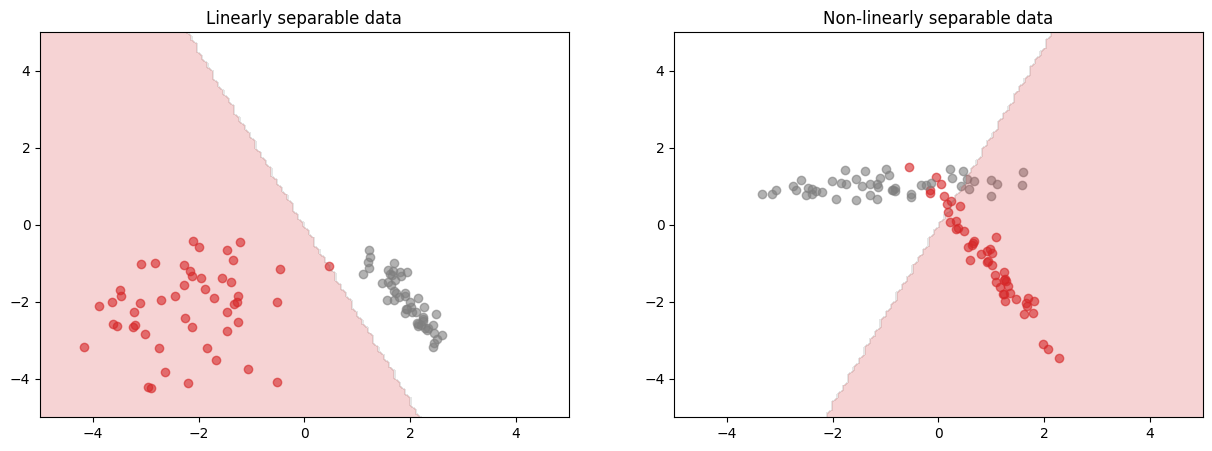

In [8]:
# number of training points
N = 100

x1, x2 = np.meshgrid(np.linspace(-5, 5, N), np.linspace(-5, 5, N))
x_test = np.array([x1, x2]).reshape(2, -1).T

model = Perceptron()

plt.figure(figsize=(15, 5))

x_train, t = make_classification(
    n_features=2,
    n_informative=2,
    n_redundant=0,
    n_classes=2,
    n_clusters_per_class=1,
    n_samples=N,
    random_state=10,
    class_sep=2,
)

model.fit(x_train, np.where(t == 0, -1, 1))
predicted = model.predict(x_test)

plt.subplot(1, 2, 1)
plt.scatter(x_train[t==1, 0], x_train[t==1, 1], alpha=0.6, c='tab:red')
plt.scatter(x_train[t==0, 0], x_train[t==0, 1], alpha=0.6, c='tab:gray')
plt.contourf(x1, x2, predicted.reshape(N, N), alpha=0.2, levels=np.linspace(0, 1, 3), colors=['tab:gray','tab:red'])
plt.xlim(-5, 5)
plt.ylim(-5, 5)
plt.title("Linearly separable data")

x_train, t = make_classification(
    n_features=2,
    n_informative=2,
    n_redundant=0,
    n_classes=2,
    n_clusters_per_class=1,
    n_samples=N,
    random_state=14,
)

model.fit(x_train, np.where(t == 0, -1, 1))
predicted = model.predict(x_test)

plt.subplot(1, 2, 2)
plt.scatter(x_train[t==1, 0], x_train[t==1, 1], alpha=0.6, c='tab:red')
plt.scatter(x_train[t==0, 0], x_train[t==0, 1], alpha=0.6, c='tab:gray')
plt.contourf(x1, x2, predicted.reshape(N, N), alpha=0.2, levels=np.linspace(0, 1, 3), colors=['tab:gray','tab:red'])
plt.xlim(-5, 5)
plt.ylim(-5, 5)
plt.title("Non-linearly separable data")

plt.show()